## Imports

In [ ]:
!pip install sklearn-som
!pip install networkx
!pip install python-louvain

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
from sklearn.metrics import pairwise_distances

from sklearn import metrics
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import SpectralClustering

from matplotlib import rcParams
rcParams['figure.figsize'] = 15 ,15

from sklearn_som.som import SOM

import networkx as nx

from sklearn.neighbors import kneighbors_graph
import community.community_louvain as community_louvain

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


## Construindo o Dataset

In [ ]:
dataset_path = './images/*.png'
images_filenames = glob.glob(dataset_path)

images_filenames = np.sort(images_filenames)

img_arry = []
for img_path in images_filenames:
  img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2GRAY)
  img_arry.append(img.flatten())

image_dataset = pd.DataFrame(img_arry)

print('shape:', image_dataset.shape)
image_dataset.head()

shape: (45, 16384)


,0,1,2,3,4,5,6,7,8,9,...,16374,16375,16376,16377,16378,16379,16380,16381,16382,16383
0,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
1,49,47,26,26,26,26,26,26,26,26,...,26,26,26,26,26,26,26,26,26,26
2,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
3,49,47,27,27,27,27,27,27,27,27,...,27,27,27,27,27,27,27,27,27,27
4,49,47,26,26,26,26,26,26,26,26,...,26,26,26,26,26,26,26,26,26,26


## Visualizando o Resultado Inicial da Clusterização

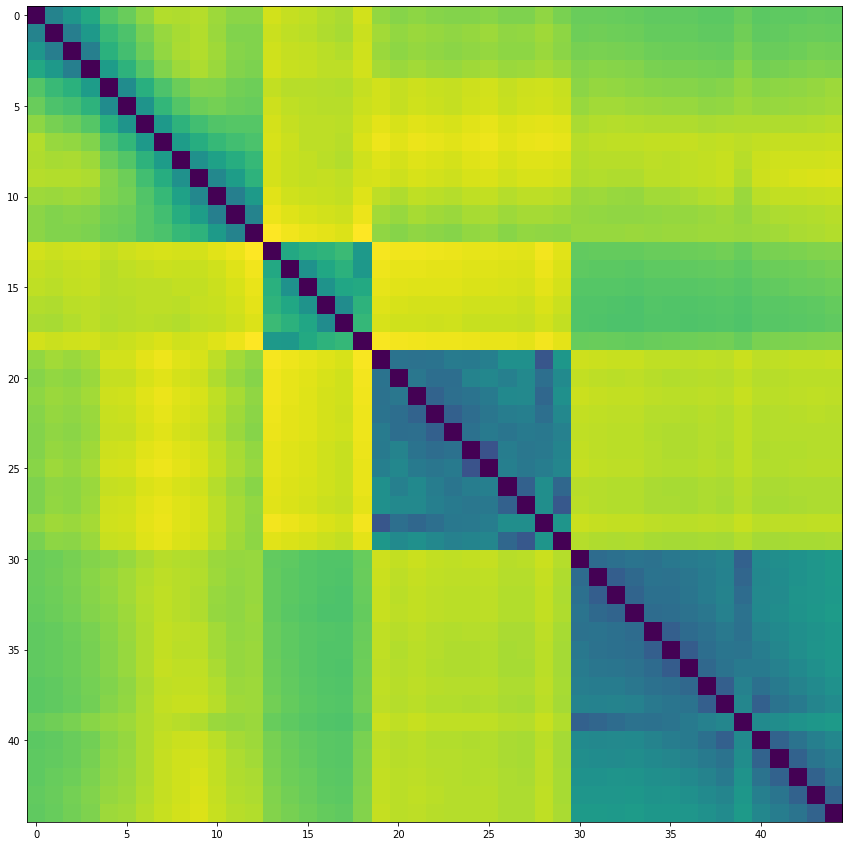

In [ ]:
p = pairwise_distances(image_dataset, metric='euclidean')
plt.imshow(p, interpolation='nearest')

# Testando Alguns Algoritmos de Clustering

In [ ]:
def plot_images_by_cluster(images_filenames, y, cluster_idx):
  print(f'cluster {cluster_idx}')

  fig, ax = plt.subplots(1, len(images_filenames[y==cluster_idx]))
  i = 0
  for path in images_filenames[y==cluster_idx]:
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2GRAY)
    ax[i].imshow(img, cmap="gray")
    i = i + 1
  plt.show()

### K-Means

(5, 16384)
cluster 0


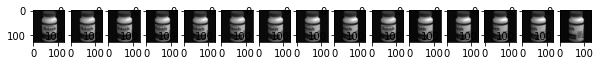

cluster 1


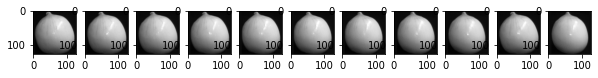

cluster 2


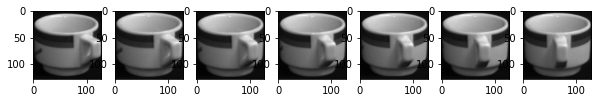

cluster 3


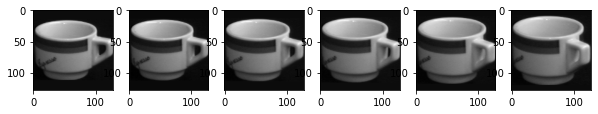

cluster 4


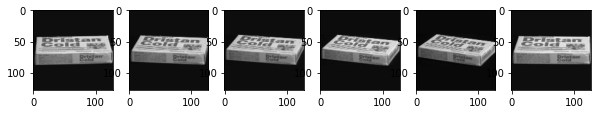

In [ ]:
# implemente o k-means
kmeans = KMeans(n_clusters=5, random_state=0).fit(image_dataset)

y_kmeans = kmeans.labels_

print(kmeans.cluster_centers_.shape)

for k in range(max(y_kmeans) + 1):
  plot_images_by_cluster(images_filenames, y_kmeans, k)

### Aglomerativo

cluster 0


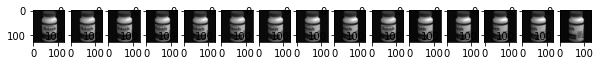

cluster 1


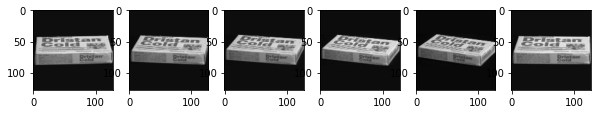

cluster 2


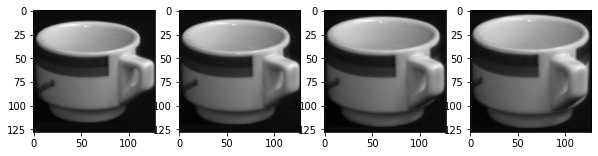

cluster 3


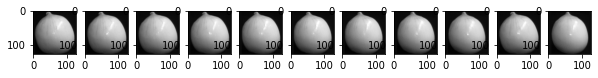

cluster 4


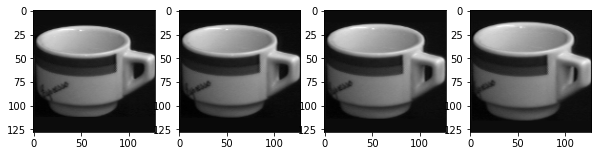

cluster 5


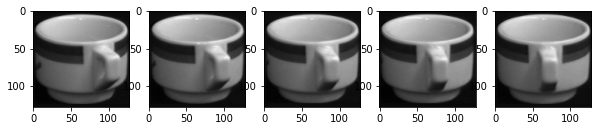

In [ ]:
# implemente o agglomerative
agglomerative = AgglomerativeClustering(n_clusters=6).fit(image_dataset)

y_agglomerative = agglomerative.labels_

for k in range(max(y_agglomerative) + 1):
  plot_images_by_cluster(images_filenames, y_agglomerative, k)

### Spectral

/usr/local/lib/python3.7/dist-packages/sklearn/manifold/_spectral_embedding.py:261: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  "Graph is not fully connected, spectral embedding may not work as expected."


cluster 0


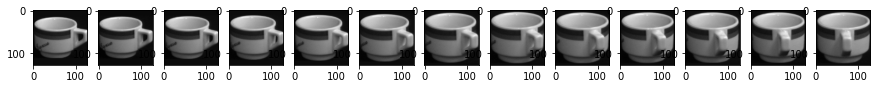

cluster 1


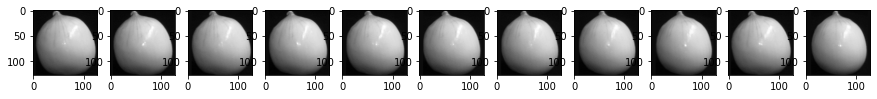

cluster 2


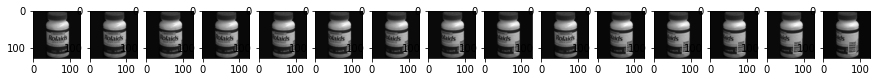

cluster 3


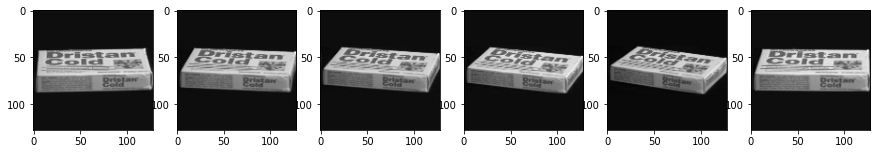

In [ ]:
# implemente o Spectral

p = pairwise_distances(image_dataset, metric='euclidean')
spectral = SpectralClustering(n_clusters=4, affinity='precomputed_nearest_neighbors', n_neighbors=5, random_state=0).fit(p)

y_spectral = spectral.labels_

plot_images_by_cluster(images_filenames, y_spectral, 0)
plot_images_by_cluster(images_filenames, y_spectral, 1)
plot_images_by_cluster(images_filenames, y_spectral, 2)
plot_images_by_cluster(images_filenames, y_spectral, 3)

### Louvain

{0: 0, 1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 1, 7: 1, 8: 1, 9: 1, 10: 1, 11: 1, 12: 1, 13: 2, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 4, 20: 4, 21: 4, 22: 4, 23: 4, 24: 4, 25: 4, 26: 4, 27: 4, 28: 4, 29: 4, 30: 5, 31: 5, 32: 5, 33: 5, 34: 5, 35: 5, 36: 5, 37: 3, 38: 3, 39: 5, 40: 3, 41: 3, 42: 3, 43: 3, 44: 3}
cluster 0


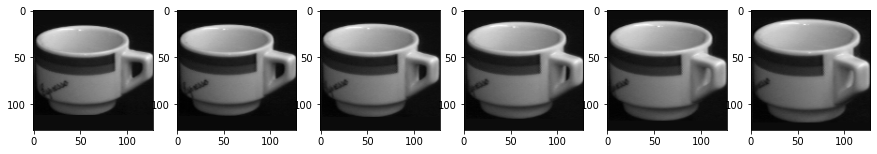

cluster 1


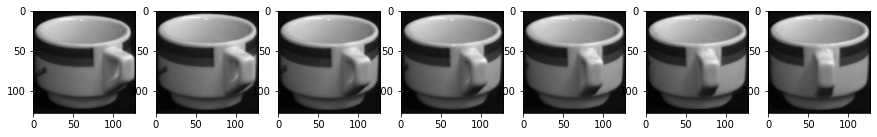

cluster 2


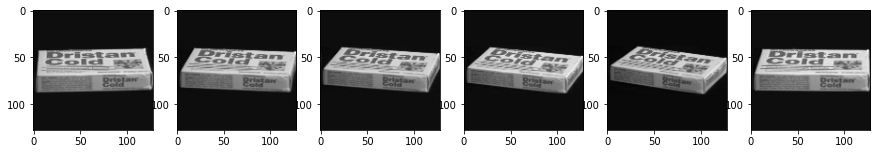

cluster 3


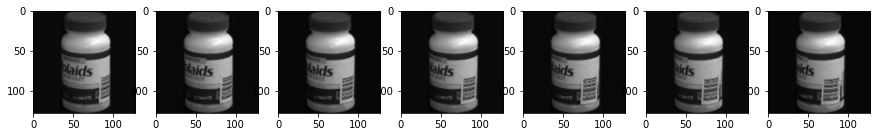

cluster 4


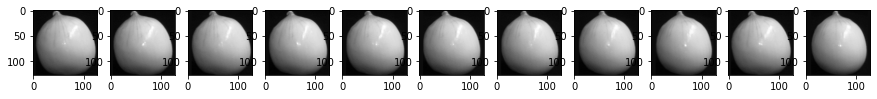

cluster 5


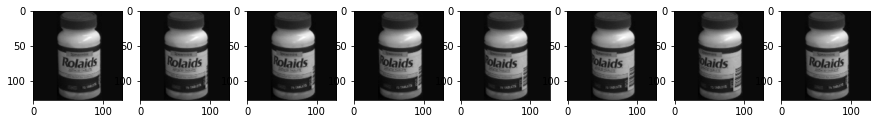

In [ ]:
A = kneighbors_graph(image_dataset, 5, mode='connectivity', include_self=False)

G = nx.from_scipy_sparse_matrix(A)
partition = community_louvain.best_partition(G, resolution=2.0, randomize=False)

print(partition)

y_louvain = np.array([i for i in partition.values()])

for k in range(max(y_louvain) + 1):
  plot_images_by_cluster(images_filenames, y_louvain, k)

## Análise dos Clusters

In [ ]:
# calcule o NMI para os algoritmos

sil_kmeans = metrics.silhouette_score(image_dataset, y_kmeans, metric='euclidean')
sil_agglomerative = metrics.silhouette_score(image_dataset, y_agglomerative, metric='euclidean')
sil_spectral = metrics.silhouette_score(image_dataset, y_spectral, metric='euclidean')
sil_louvain = metrics.silhouette_score(image_dataset, y_louvain, metric='euclidean')

print('Silhueta kmeans', sil_kmeans)
print('Silhueta agglomerative', sil_agglomerative)
print('Silhueta spectral', sil_spectral)
print('Silhueta louvain', sil_louvain)

print('\n')

y_true = [path.split('/')[2].split('__')[0] for path in images_filenames]

nmi_kmeans = metrics.normalized_mutual_info_score(y_true, y_kmeans)
nmi_agglomerative = metrics.normalized_mutual_info_score(y_true, y_agglomerative)
nmi_spectral = metrics.normalized_mutual_info_score(y_true, y_spectral)
nmi_louvain = metrics.normalized_mutual_info_score(y_true, y_louvain)

print('NMI Kmeans: ', nmi_kmeans)
print('NMI Aglomerativo: ', nmi_agglomerative)
print('NMI Spectral: ', nmi_spectral)
print('NMI Louvain: ', nmi_louvain)

Silhueta kmeans 0.3495950936073754
Silhueta agglomerative 0.3495950936073754
Silhueta spectral 0.3495950936073754
Silhueta louvain 0.2891968273492412


NMI Kmeans:  1.0000000000000002
NMI Aglomerativo:  1.0
NMI Spectral:  1.0
NMI Louvain:  0.8616376351602065


In [ ]:
print(len(y_true))
print(y_true)

45
['obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj10', 'obj1', 'obj1', 'obj1', 'obj1', 'obj1', 'obj1', 'obj2', 'obj2', 'obj2', 'obj2', 'obj2', 'obj2', 'obj2', 'obj2', 'obj2', 'obj2', 'obj2', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5', 'obj5']


In [ ]:
print(len(y_kmeans))
y_louvain

45


array([0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 4, 4, 4,
       4, 4, 4, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 5, 5, 3, 3, 5, 3, 3, 3, 3,
       3])

## Detecção do Número de Clusters

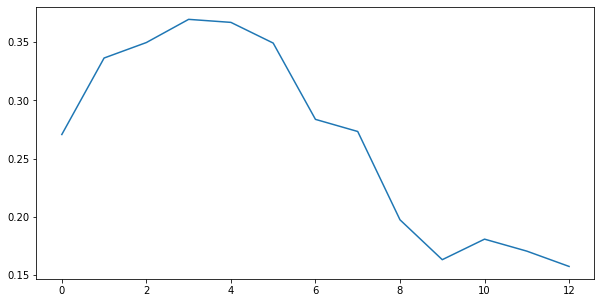

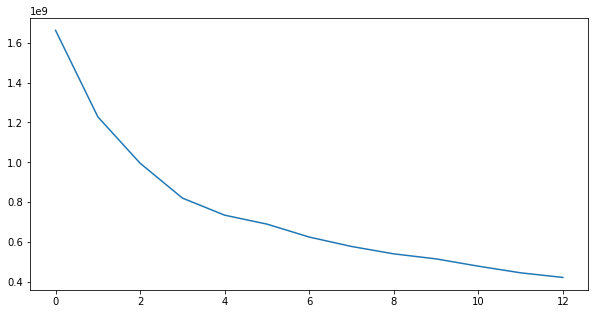

In [ ]:
rcParams['figure.figsize'] = 10 ,5

sils = []
inertias = []

for k in range(2, 15):
  model = KMeans(n_clusters=k, random_state=0).fit(image_dataset)  

  y_labels = model.labels_
  sil = metrics.silhouette_score(image_dataset, y_labels, metric='euclidean')

  inertias.append(model.inertia_)
  sils.append(sil)

plt.plot(sils)
plt.show()

plt.plot(inertias)

## Visualização dos Clusters

(45, 2)


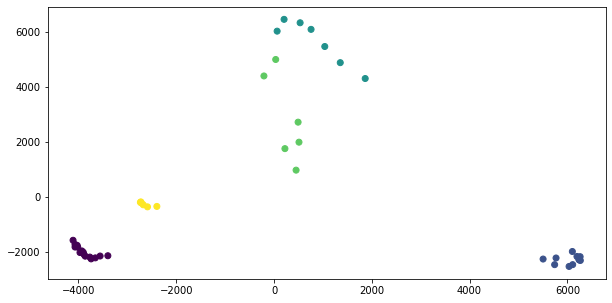

In [ ]:
X = PCA(n_components=2).fit_transform(image_dataset)
print(X.shape)
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans)